In [1]:
# Acesso à raiz do projeto

import sys
import os

# Caminho até a raiz do projeto
sys.path.append(os.path.abspath("../../"))


In [2]:
# Importação das bibliotecas necessárias

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from modulos.gerais import exibir_resultado, exibir_relatorio_de_classificacao, preparar_iris
from modulos.arvore_de_decisao import executar_arvore_de_decisao, exibir_regras_da_arvore_de_decisao, gerar_grafico_da_arvore_de_decisao


In [3]:
# Importação e exploração dos dados
iris = load_iris()
X, y, feature_names, target_names = preparar_iris(iris)

# Divisão em Treino (70%) e Teste (30%) com semente fixa para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=13, stratify=y
)


In [4]:
(clf, y_pred_arvore_de_decisao, acuracia_arvore_decisao, precisao_arvore_decisao,
revocacao_arvore_decisao, f1_arvore_decisao) = executar_arvore_de_decisao(X_train, y_train, X_test, y_test)


In [5]:
# Exibição dos resultados das métricas usando Árvore de Decisão com Iris
exibir_resultado(
    acuracia_arvore_decisao, precisao_arvore_decisao,
    revocacao_arvore_decisao, f1_arvore_decisao,
    "ÁRVORE DE DECISÃO"
    )


MÉTRICAS DE AVALIAÇÃO - ÁRVORE DE DECISÃO
Acurácia:  0.9556
Precisão:  0.9608
Revocação: 0.9556
F1-Score:  0.9554




In [6]:
# Exibição das Regras Geradas
exibir_regras_da_arvore_de_decisao(clf, feature_names)



REGRAS DA ÁRVORE DE DECISÃO (FORMATO TEXTO):
|--- petal width (cm) <= 0.80
|   |--- class: 0
|--- petal width (cm) >  0.80
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- class: 2
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- class: 2



In [7]:
# Exibição do relatório de classificação da Árvore de Decisão com Iris
exibir_relatorio_de_classificacao(y_test, y_pred_arvore_de_decisao, iris)


==================== RELATÓRIO DE CLASSIFICAÇÃO ====================
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.87      0.93        15
   virginica       0.88      1.00      0.94        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



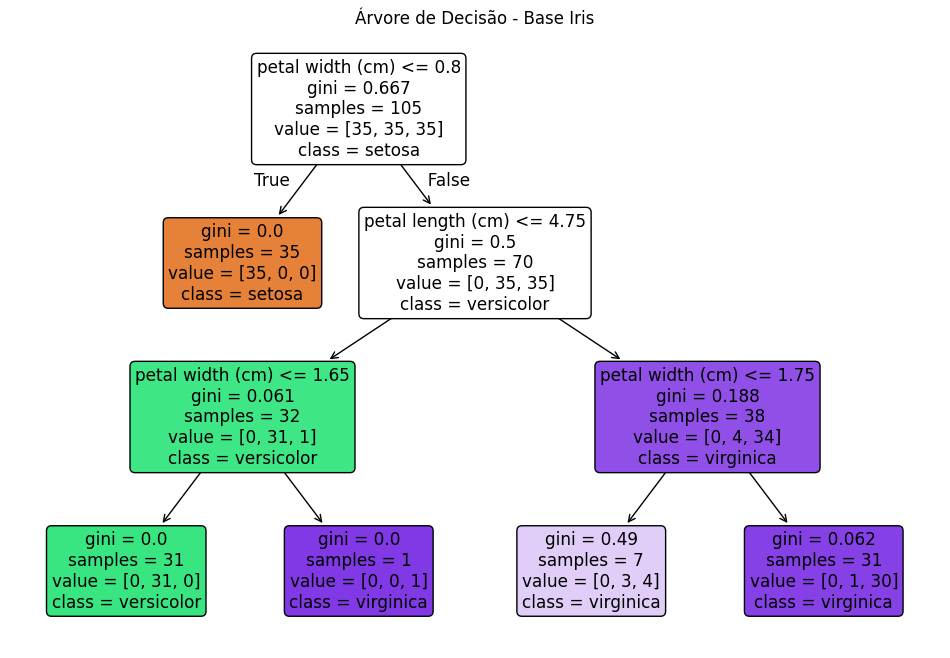

In [8]:
# Representação Gráfica da Árvore
gerar_grafico_da_arvore_de_decisao(clf, feature_names, target_names, 'Iris')
